In [2]:
import os

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from sklearn.metrics import multilabel_confusion_matrix, classification_report, ConfusionMatrixDisplay

import sys
sys.path.append('../')

#physionet functions
from driver import load_challenge_data, get_classes

In [3]:
base_path = Path('../')
input_path = base_path.joinpath('input_directory')
print(input_path.absolute())

C:\Users\riehlmn\PycharmProjects\physionet\physionet2020\notebooks\..\input_directory


In [4]:
# copy from driver.py
input_files = []
for f in os.listdir(input_path.absolute()):
    if os.path.isfile(os.path.join(str(input_path), f)) and not f.lower().startswith('.') and f.lower().endswith('mat'):
        input_files.append(f)

classes = get_classes(str(input_path),input_files)
num_classes = len(classes)
num_files = len(input_files)

header = []
pred = []
label = []
for i, file in enumerate(input_files):
    data,header_data = load_challenge_data(str(input_path.joinpath(file)))
    header.append(header_data)
    current_label = np.zeros(num_classes, dtype=int)
    for line in header_data:
        if line.startswith('#Dx: '):
            dx = line.split(': ')[1].split(',')
            for d in dx:
                d = d.strip()
                current_label[classes.index(d)] = 1
    label.append(current_label)
    if not (current_label - [0, 0, 0, 0, 0, 0, 0, 1, 1]).any():
        print(current_label)
        print(dx)
    random_pred = np.random.randint(6, size=num_classes) # add random prediction for testing
    random_pred = np.where(random_pred < 5, 0, 1)
    pred.append(random_pred)
    
label = np.array(label)
pred = np.array(pred)

[0 0 0 0 0 0 0 1 1]
['STD', 'STE\n']
[0 0 0 0 0 0 0 1 1]
['STD', 'STE\n']


# Confussion matrices for binary classes

In [7]:
# confussion matrix for each binary class of format [[TP, FP], [FN, TN]] 
# where TP are true positives, FP are false positives, FN are fasle negatives and TN are true negatives
def confusion_matrices_bc(y_true, y_pred, num_classes, normalize=True): # confusion_matrices_binary_classes
    cm = np.zeros((num_classes, 2, 2))
    for i in range(len(y_true)):
        num_labels = np.sum(y_true[i])
        for j in range(num_classes):
            if normalize:    # normalization as proposed by Challange scoring system
                cm[j][1-y_pred[i][j]][1-y_true[i][j]] += 1 / num_labels
            else:
                cm[j][1-y_pred[i][j]][1-y_true[i][j]] += 1
    return cm

cm = confusion_matrices_bc(label, pred, num_classes, normalize=True)
# for i in range(len(cm)):
#     print(classes[i] + '\npredictions: ' + str(pred[:, i]) + '\n     labels: ' + str(label[:, i])
#           + '\nconfussion matrix: [' + str(cm[i][0]) + '\n\t\t    ' + str(cm[i][1]) + ']')

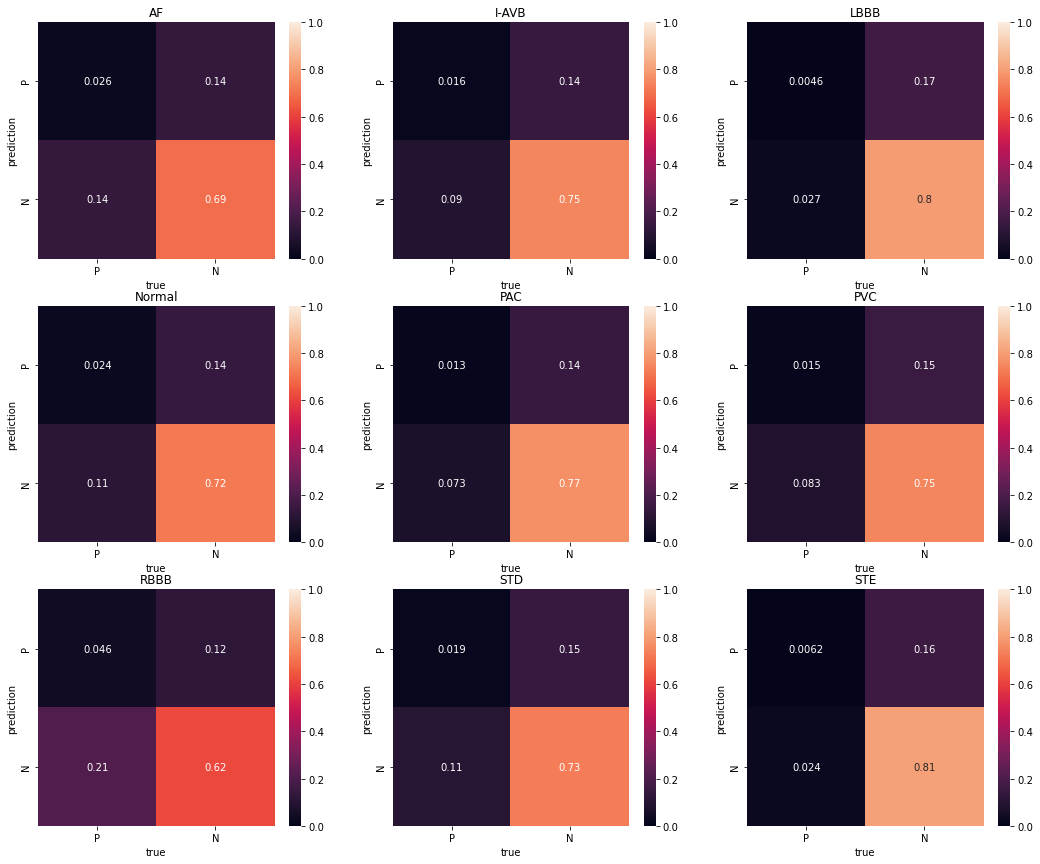

In [12]:
def show_confusion_matrices_bc(cm, normalize=True):
    fig = plt.figure(figsize=(18, 20))
    for i in range(len(cm)):
        ax = fig.add_subplot(4, 3, i + 1)
        if normalize:
            cm_df = pd.DataFrame(cm[i] / np.sum(cm[i]), index=['P', 'N'], columns=['P', 'N'])
            sn.heatmap(cm_df, vmin=0, vmax=1, annot=True)
        else:
            cm_df = pd.DataFrame(cm[i], index=['P', 'N'], columns=['P', 'N'])
            sn.heatmap(cm_df, annot=True)
        plt.xlabel('true')
        plt.ylabel('prediction')
        plt.title(classes[i])
        
show_confusion_matrices_bc(cm, normalize=True)

matrices calculated with sklearn.metrics:
 [[[4707  949]
  [1033  188]]

 [[5166  989]
  [ 614  108]]

 [[5478 1163]
  [ 200   36]]

 [[4975  984]
  [ 761  157]]

 [[5272  989]
  [ 523   93]]

 [[5134 1043]
  [ 592  108]]

 [[4179  841]
  [1528  329]]

 [[5005 1003]
  [ 734  135]]

 [[5543 1114]
  [ 176   44]]]


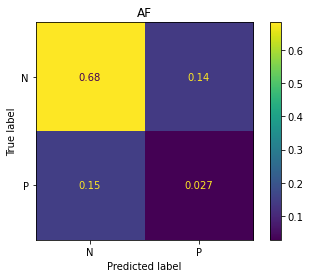

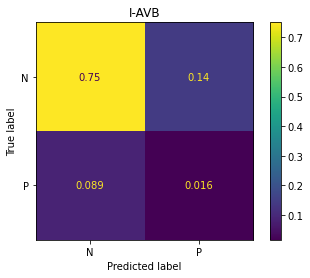

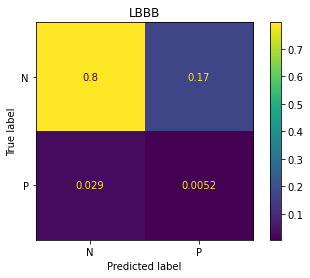

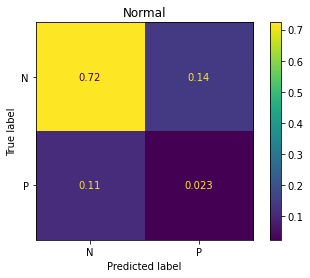

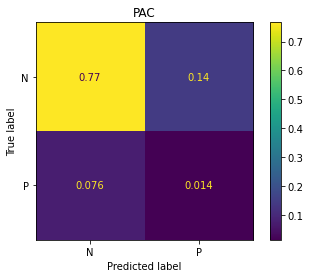

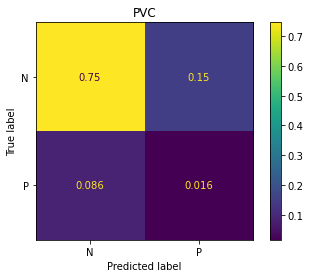

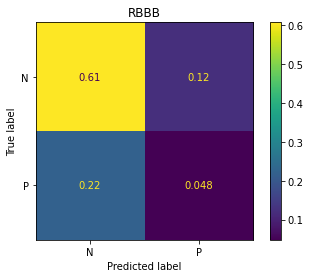

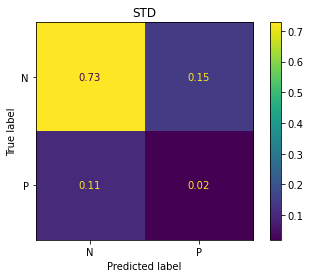

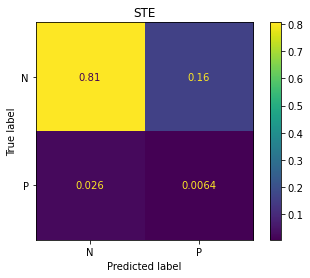

In [14]:
# found a function from sklearn.metrics. note: uses format [[TN, FP], [FN, TP]]
# offers no normalization as proposed by Challange scoring system
skcm = multilabel_confusion_matrix(label, pred)
print('matrices calculated with sklearn.metrics:\n', skcm)

for i in range(len(skcm)):
    ConfusionMatrixDisplay(skcm[i] / np.sum(skcm[i]), ['N', 'P']).plot(include_values=True) # no min and max attribute for colorbar
    plt.title(classes[i])

### Classification report for binary classes

In [15]:
# standard classification report from sklearn.metrics
report = classification_report(label, pred, target_names=classes)
print(report)

              precision    recall  f1-score   support

          AF       0.17      0.15      0.16      1221
       I-AVB       0.10      0.15      0.12       722
        LBBB       0.03      0.15      0.05       236
      Normal       0.14      0.17      0.15       918
         PAC       0.09      0.15      0.11       616
         PVC       0.09      0.15      0.12       700
        RBBB       0.28      0.18      0.22      1857
         STD       0.12      0.16      0.13       869
         STE       0.04      0.20      0.06       220

   micro avg       0.12      0.16      0.14      7359
   macro avg       0.12      0.16      0.12      7359
weighted avg       0.16      0.16      0.15      7359
 samples avg       0.09      0.16      0.11      7359



c:\users\riehlmn\anaconda3\envs\physionet\lib\site-packages\sklearn\metrics\_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [20]:
# Score calculations copied from (master) evaluate_12ECG_score.compute_beta_score and adapted
def compute_beta_score(cm, num_recordings, num_classes, beta, augmented=True): # augemented return statements -> score for each class
    fbeta_l = np.zeros(num_classes)
    gbeta_l = np.zeros(num_classes)
    fmeasure_l = np.zeros(num_classes)
    accuracy_l = np.zeros(num_classes)

    f_beta = 0
    g_beta = 0
    f_measure = 0
    accuracy = 0

    # Weight function
    C_l=np.ones(num_classes);

    for j in range(num_classes):
        tp = cm[j][0][0]
        fp = cm[j][0][1]
        fn = cm[j][1][0]
        tn = cm[j][1][1]

#         tp = 0 
#         fp = 0
#         fn = 0
#         tn = 0

#         for i in range(num_recordings):

#             num_labels = np.sum(label[i])

#             if label[i][j] and pred[i][j]:
#                 tp += 1/num_labels
#             elif not label[i][j] and pred[i][j]:
#                 fp += 1/num_labels
#             elif label[i][j] and not pred[i][j]:
#                 fn += 1/num_labels
#             elif not label[i][j] and not pred[i][j]:
#                 tn += 1/num_labels
    
        # Summarize contingency table.
        if ((1+beta**2)*tp + (fn*beta**2) + fp):
            fbeta_l[j] = float((1+beta**2)* tp) / float(((1+beta**2)*tp) + (fn*beta**2) + fp)
        else:
            fbeta_l[j] = 1.0

        if (tp + fp + beta * fn):
            gbeta_l[j] = float(tp) / float(tp + fp + beta*fn)
        else:
            gbeta_l[j] = 1.0

        if tp + fp + fn + tn:
            accuracy_l[j] = float(tp + tn) / float(tp + fp + fn + tn)
        else:
            accuracy_l[j] = 1.0

        if 2 * tp + fp + fn:
            fmeasure_l[j] = float(2 * tp) / float(2 * tp + fp + fn)
        else:
            fmeasure_l[j] = 1.0

    for i in range(num_classes):
        f_beta += fbeta_l[i]*C_l[i]
        g_beta += gbeta_l[i]*C_l[i]
        f_measure += fmeasure_l[i]*C_l[i]
        accuracy += accuracy_l[i]*C_l[i]

    f_beta = float(f_beta)/float(num_classes)
    g_beta = float(g_beta)/float(num_classes)
    f_measure = float(f_measure)/float(num_classes)
    accuracy = float(accuracy)/float(num_classes)
    
    if augmented:
        return f_beta, g_beta, f_measure, accuracy, fbeta_l, gbeta_l, fmeasure_l, accuracy_l
    else:
        return f_beta, g_beta, f_measure, accuracy

In [42]:
def get_report(cm, classes):
    metrics = ['precision', 'recall', 'accuracy', 'f_measure', 'f_beta', 'g_beta', 'support']
    report_df = pd.DataFrame(np.zeros((len(classes), len(metrics))), index=classes, columns=metrics)

    f_beta, g_beta, f_measure, accuracy, fbeta_l, gbeta_l, fmeasure_l, accuracy_l = compute_beta_score(cm, len(label), num_classes, 2, augmented=True)
    for i in range(len(classes)):
        precision_l = cm[i][0][0] / (cm[i][0][0] + cm[i][0][1])
        recall_l = cm[i][0][0] / (cm[i][0][0] + cm[i][1][0])
        report_df.loc[classes[i]] = [precision_l , recall_l, accuracy_l[i], fmeasure_l[i], fbeta_l[i],
                                     gbeta_l[i], np.sum(cm[i][:, 0])]

    cm_total = np.sum(cm, axis=0)
    precision = cm_total[0][0] / (cm_total[0][0] + cm_total[0][1])
    recall = cm_total[0][0] / (cm_total[0][0] + cm_total[1][0])  

    report_df.loc['Total'] = [precision, recall, accuracy, f_measure, f_beta, g_beta, np.sum(cm[:,:,0])]
    return report_df

report = get_report(cm, classes)
report.head(n=num_classes + 1)
# print(report_df)
# print(num_recordings)

,precision,recall,accuracy,f_measure,f_beta,g_beta,support
AF,0.155862,0.156193,0.720498,0.156027,0.156127,0.058070,1098.0
I-AVB,0.099422,0.150568,0.765266,0.119763,0.136522,0.046858,704.0
LBBB,0.026358,0.146538,0.804585,0.044679,0.076644,0.020166,207.0
Normal,0.142966,0.171024,0.743572,0.155741,0.164564,0.059920,918.0
PAC,0.082578,0.150697,0.781787,0.106691,0.129355,0.042769,574.0
PVC,0.090882,0.155318,0.763885,0.114668,0.136029,0.045704,653.5
RBBB,0.269748,0.179699,0.666416,0.215702,0.192555,0.077900,1694.5
STD,0.115158,0.153753,0.747690,0.131686,0.144094,0.050783,826.0
STE,0.036415,0.202145,0.812946,0.061713,0.105822,0.028284,202.0
Total,0.113278,0.163613,0.756294,0.122963,0.137968,0.047828,6877.0


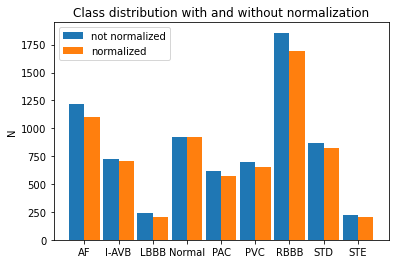

In [38]:
# class distribution with and without normalization
report_dict = classification_report(label, pred, target_names=classes, output_dict=True)
dist_sk = np.zeros(num_classes)
for i, cl in enumerate(classes):
    dist_sk[i] = report_dict[cl]['support']
dist_normalized = report_df.loc[:'STE','support'].values

x = np.arange(num_classes)
width = 0.45
fig, ax = plt.subplots()
without_n = ax.bar(x - width/2, dist_sk, width, label='not normalized')
with_n = ax.bar(x + width/2, dist_normalized, width, label='normalized')

ax.set_title('Class distribution with and without normalization')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel('N')
ax.legend()

# Confussion matrix for all combinations

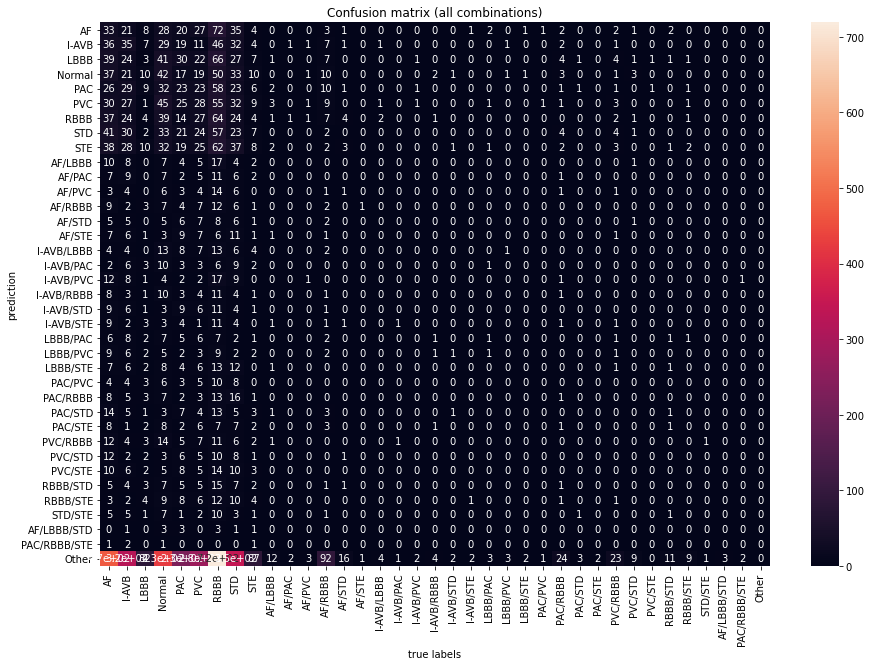

In [48]:
def compute_confusion_matrix(y_true, y_pred, classes):
    labels_combined = np.unique(y_true, axis=0)
    num_combined_classes = len(labels_combined)
    classes = np.array(classes) # in order to use some np.array specific operations

    labels2string = lambda l: '/'.join(classes[np.nonzero(l)])
    classes_combined = [labels2string(l) for l in labels_combined] # get string representation of each combination

    classes_combined.sort() # put it in a nice order
    classes_combined.sort(key=lambda s: s.count('/'))
    classes_combined.append('Other') # in case of a predicted combination thats not in classes_combined (the true label combinations)
    # print(classes_combined)

    cm_all = np.zeros((num_combined_classes + 1, num_combined_classes + 1))
    cm_all_df = pd.DataFrame(cm_all, index=classes_combined, columns=classes_combined)

    for i in range(len(y_pred)):
        row = labels2string(pred[i])
        col = labels2string(label[i])
        try:
            cm_all_df.at[row, col] += 1
        except KeyError:
            cm_all_df.at['Other', col] += 1
    return cm_all_df

def show_confussion_matrix(cm):
    fig = plt.figure(figsize=(15, 10))
    sn.heatmap(cm_all_df.loc[:,:], annot=True)
    plt.xlabel('true labels')
    plt.ylabel('prediction')
    plt.title('Confusion matrix (all combinations)')
    
cm = compute_confusion_matrix(label, pred, classes)
show_confussion_matrix(cm)